# Process Mining Group 5 notebook

## Directly-Follows Graph (overview)

A quick DFG of the full event log (`complete` events only) to get an overview of the process
before scoping and mining the individual sub-processes.


parsing log, completed traces :: 100%|██████████| 7065/7065 [00:01<00:00, 4424.85it/s]


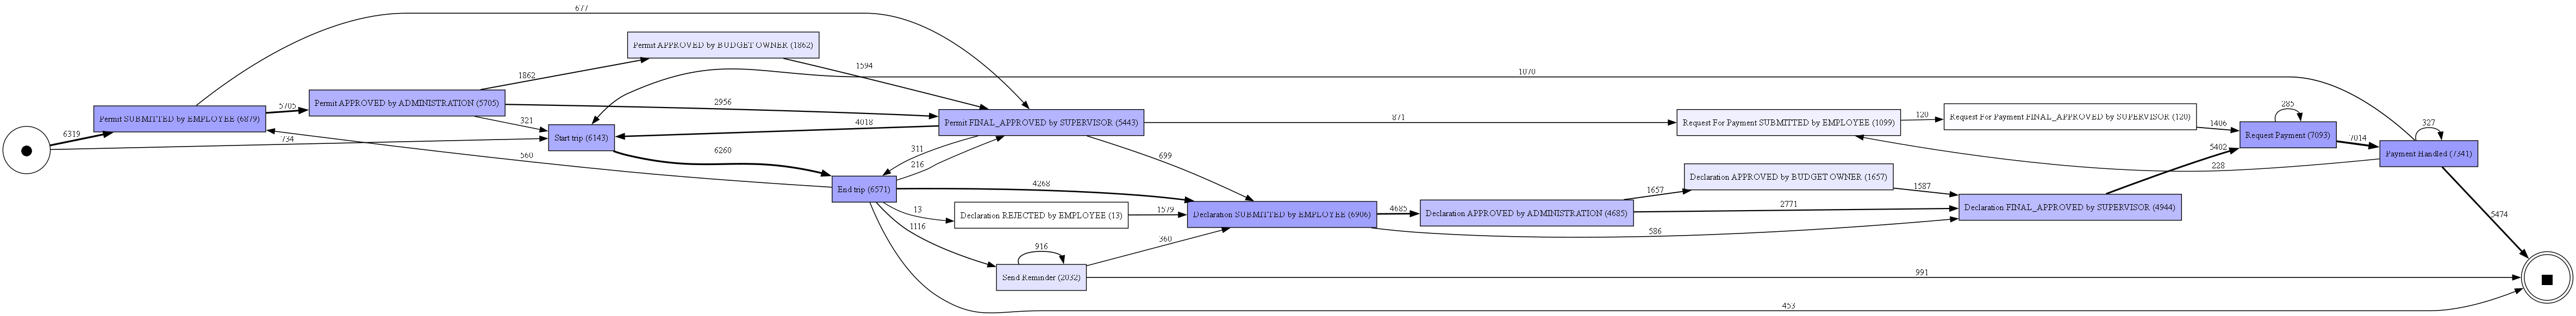

In [ ]:
import os
import pandas as pd
import pm4py
from pm4py.algo.filtering.dfg import dfg_filtering

CASE_ID = "case:concept:name"
ACTIVITY = "concept:name"
TIMESTAMP = "time:timestamp"
LIFECYCLE = "lifecycle:transition"

XES_PATH = "PermitLog.xes"
OUTPUT_FOLDER = "Output"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

dfg_log = pm4py.read_xes(XES_PATH)
dfg_log = pm4py.convert_to_dataframe(dfg_log)

if LIFECYCLE in dfg_log.columns:
    _complete = dfg_log[LIFECYCLE].astype(str).str.lower().eq("complete")
    if _complete.any():
        dfg_log = dfg_log[_complete].copy()

dfg_log = dfg_log[[CASE_ID, ACTIVITY, TIMESTAMP]].dropna().copy()
dfg_log[TIMESTAMP] = pd.to_datetime(dfg_log[TIMESTAMP], errors="coerce", utc=True)
dfg_log = dfg_log.dropna(subset=[TIMESTAMP])
dfg_log = dfg_log.sort_values([CASE_ID, TIMESTAMP]).reset_index(drop=True)

dfg, start_activities, end_activities = pm4py.discover_dfg(
    dfg_log, activity_key=ACTIVITY, timestamp_key=TIMESTAMP, case_id_key=CASE_ID,
)

activities_count = dfg_log[ACTIVITY].value_counts().to_dict()
dfg, start_activities, end_activities, activities_count = dfg_filtering.filter_dfg_on_activities_percentage(
    dfg, start_activities, end_activities, activities_count, 0.30,
)
dfg, start_activities, end_activities, activities_count = dfg_filtering.filter_dfg_on_paths_percentage(
    dfg, start_activities, end_activities, activities_count, 0.20,
)

pm4py.save_vis_dfg(
    dfg, start_activities, end_activities,
    os.path.join(OUTPUT_FOLDER, "permitlog_dfg.png"),
    rankdir="TB",
)
pm4py.view_dfg(dfg, start_activities, end_activities, rankdir="TB")


## Preprocessing & data quality

Applied in the discovery cell before mining:

1. Keep only `complete` lifecycle events.
2. Drop exact duplicate `(case, activity, timestamp)` rows.
3. Stable event ordering: events are sorted by `(case, timestamp)` and ties on equal timestamps are broken by original log order (`ORDER`) rather than alphabetically by activity name, so no false directly-follows relations are invented.
4. Scope mining per object flow (Permit, Declaration, Request For Payment) to avoid a spaghetti model. Activities that have no flow-specific name prefix are attached to the flow they belong to: `Start trip` / `End trip` join the Permit flow (a trip is authorised by a permit), and `Request Payment` / `Payment Handled` join the Request For Payment flow (they settle a request for payment).
5. Tail-step ordering: the attached activities carry planned/booking timestamps that do not reflect their position in the control flow (e.g. a `Start trip` date can precede the permit's final approval), so they are placed after the prefix flow in their natural order (`Start trip` → `End trip`, `Request Payment` → `Payment Handled`) and a monotonic per-case timestamp is rebuilt from that order so the miners honour it. This stops them being drawn as a disconnected parallel path.
6. Keep only complete cases (last activity contains `FINAL_APPROVED` or `REJECTED`, or the flow's trailing step `End trip` / `Payment Handled`).
7. Keep only proper-start cases (first activity contains `SUBMITTED`), removing head-truncated cases whose start falls outside the log window.
8. Rare-activity filter (`MIN_ACTIVITY_FREQ`): within each sub-process, drop activities occurring in fewer than 1% of that flow's cases (set to `0` to disable).


## Discovery & evaluation

- Miners: Heuristics and Inductive
- Metrics: fitness, precision, generalization, simplicity, plus F-score and their mean.
- Each sub-process is mined on samples and on all of its cases; nets are saved as PNML and the best per sub-process as PNG.


In [16]:
import os
import re
import pandas as pd
import pm4py

CASE_ID = "case:concept:name"
ACTIVITY = "concept:name"
TIMESTAMP = "time:timestamp"
LIFECYCLE = "lifecycle:transition"
MIN_ACTIVITY_FREQ = 0.01

XES_PATH = "PermitLog.xes"
OUTPUT_FOLDER = "Output"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
log = pm4py.read_xes(XES_PATH)
df = pm4py.convert_to_dataframe(log)

if LIFECYCLE in df.columns:
    complete_mask = df[LIFECYCLE].astype(str).str.lower().eq("complete")
    if complete_mask.any():
        df = df[complete_mask].copy()

df = df[[CASE_ID, ACTIVITY, TIMESTAMP]].dropna().copy()
df[TIMESTAMP] = pd.to_datetime(df[TIMESTAMP], errors="coerce", utc=True)
df = df.dropna(subset=[TIMESTAMP])
df = df.drop_duplicates(subset=[CASE_ID, ACTIVITY, TIMESTAMP]).copy()
df = df.sort_values([CASE_ID, TIMESTAMP, ACTIVITY]).reset_index(drop=True)

SUBPROCESSES = {
    "permit":              {"prefixes": ["Permit"],              "extra": ["Start trip", "End trip"],            "end": ["FINAL_APPROVED", "REJECTED", "End trip"]},
    "declaration":         {"prefixes": ["Declaration"],         "extra": [],                                    "end": ["FINAL_APPROVED", "REJECTED"]},
    "request_for_payment": {"prefixes": ["Request For Payment"], "extra": ["Request Payment", "Payment Handled"], "end": ["FINAL_APPROVED", "REJECTED", "Payment Handled"]},
}

BASE_SAMPLE_SIZES = [250, 500, 1000]

heuristics_settings = [
    {"dependency_threshold": 0.20, "and_threshold": 0.40, "loop_two_threshold": 0.20},
    {"dependency_threshold": 0.30, "and_threshold": 0.50, "loop_two_threshold": 0.30},
    {"dependency_threshold": 0.40, "and_threshold": 0.60, "loop_two_threshold": 0.40},
]

inductive_settings = [
    {"noise_threshold": 0.00},
    {"noise_threshold": 0.05},
    {"noise_threshold": 0.10},
]

DECISION_METRICS = ["fitness_log", "precision", "generalization", "simplicity"]

def reduce_net(net, im, fm):
    net = pm4py.reduce_petri_net_invisibles(net)
    net, im, fm = pm4py.reduce_petri_net_implicit_places(net, im, fm)
    return net, im, fm

def evaluate_net(net, im, fm, eval_df):
    fit = pm4py.fitness_token_based_replay(
        eval_df, net, im, fm,
        activity_key=ACTIVITY, timestamp_key=TIMESTAMP, case_id_key=CASE_ID,
    )
    metrics = {
        "fitness_log": fit.get("log_fitness"),
        "fitness_average_trace": fit.get("average_trace_fitness"),
        "fitting_traces_percent": fit.get("percentage_of_fitting_traces"),
        "precision": pm4py.precision_token_based_replay(
            eval_df, net, im, fm,
            activity_key=ACTIVITY, timestamp_key=TIMESTAMP, case_id_key=CASE_ID,
        ),
        "generalization": pm4py.generalization_tbr(
            eval_df, net, im, fm,
            activity_key=ACTIVITY, timestamp_key=TIMESTAMP, case_id_key=CASE_ID,
        ),
        "simplicity": pm4py.simplicity_petri_net(net, im, fm),
        "f_score": None,
        "avg_score_percent": None,
    }
    f, p = metrics["fitness_log"], metrics["precision"]
    if f is not None and p is not None and (f + p) > 0:
        metrics["f_score"] = 2 * f * p / (f + p)
    available = [metrics[k] for k in DECISION_METRICS if metrics[k] is not None]
    if available:
        metrics["avg_score_percent"] = round(100 * sum(available) / len(available), 2)
    return metrics

results = []

for sp_name, sp in SUBPROCESSES.items():
    extra_list = sp.get("extra", [])
    prefix_mask = df[ACTIVITY].str.startswith(tuple(sp["prefixes"]))
    extra_mask = df[ACTIVITY].isin(extra_list)
    sp_df = df[prefix_mask | extra_mask].copy()

    extra_rank = {a: i for i, a in enumerate(extra_list)}
    sp_df["_phase"] = sp_df[ACTIVITY].isin(extra_list).astype(int)
    sp_df["_rank"] = sp_df[ACTIVITY].map(extra_rank).fillna(-1).astype(int)
    order_cols = [CASE_ID, "_phase", "_rank", TIMESTAMP, ACTIVITY]
    sp_df = sp_df.sort_values(order_cols).reset_index(drop=True)

    if sp.get("end"):
        last_act = sp_df.groupby(CASE_ID)[ACTIVITY].last()
        end_pattern = "|".join(re.escape(e) for e in sp["end"])
        keep_cases = last_act[last_act.str.contains(end_pattern, regex=True)].index
        sp_df = sp_df[sp_df[CASE_ID].isin(keep_cases)].copy()

    if sp_df.empty:
        continue

    if MIN_ACTIVITY_FREQ > 0:
        cases_per_activity = sp_df.groupby(ACTIVITY)[CASE_ID].nunique()
        min_cases = MIN_ACTIVITY_FREQ * sp_df[CASE_ID].nunique()
        keep_activities = cases_per_activity[cases_per_activity >= min_cases].index
        sp_df = sp_df[sp_df[ACTIVITY].isin(keep_activities)].copy()

    if sp_df.empty:
        continue

    sp_df = sp_df.sort_values(order_cols).reset_index(drop=True)
    seq = sp_df.groupby(CASE_ID).cumcount()
    sp_df[TIMESTAMP] = pd.Timestamp("2000-01-01", tz="UTC") + pd.to_timedelta(seq, unit="m")
    sp_df = sp_df.drop(columns=["_phase", "_rank"])

    all_cases = (
        pd.Series(sp_df[CASE_ID].unique()).sample(frac=1, random_state=42).tolist()
    )
    total_cases = len(all_cases)

    case_sample_sizes = [x for x in BASE_SAMPLE_SIZES if x < total_cases]
    case_sample_sizes.append(total_cases)

    for sample_size in case_sample_sizes:
        selected_cases = all_cases[:sample_size]
        eval_df = sp_df[sp_df[CASE_ID].isin(selected_cases)].copy()
        eval_df = eval_df.sort_values([CASE_ID, TIMESTAMP]).reset_index(drop=True)

        for setting in heuristics_settings:
            label = (
                sp_name + "_heuristics_cases_" + str(sample_size)
                + "_dep_" + str(setting["dependency_threshold"]).replace(".", "_")
                + "_and_" + str(setting["and_threshold"]).replace(".", "_")
                + "_loop2_" + str(setting["loop_two_threshold"]).replace(".", "_")
            )
            net, im, fm = pm4py.discover_petri_net_heuristics(eval_df, **setting)
            net, im, fm = reduce_net(net, im, fm)
            metrics = evaluate_net(net, im, fm, eval_df)
            pm4py.write_pnml(net, im, fm, os.path.join(OUTPUT_FOLDER, label + ".pnml"))
            results.append({
                "subprocess": sp_name,
                "algorithm": "Heuristics Miner",
                "sample_cases": sample_size,
                "sample_events": len(eval_df),
                "dependency_threshold": setting["dependency_threshold"],
                "and_threshold": setting["and_threshold"],
                "loop_two_threshold": setting["loop_two_threshold"],
                "noise_threshold": None,
                **metrics,
            })

        for setting in inductive_settings:
            label = (
                sp_name + "_inductive_cases_" + str(sample_size)
                + "_noise_" + str(setting["noise_threshold"]).replace(".", "_")
            )
            net, im, fm = pm4py.discover_petri_net_inductive(eval_df, **setting)
            net, im, fm = reduce_net(net, im, fm)
            metrics = evaluate_net(net, im, fm, eval_df)
            pm4py.write_pnml(net, im, fm, os.path.join(OUTPUT_FOLDER, label + ".pnml"))
            results.append({
                "subprocess": sp_name,
                "algorithm": "Inductive Miner",
                "sample_cases": sample_size,
                "sample_events": len(eval_df),
                "dependency_threshold": None,
                "and_threshold": None,
                "loop_two_threshold": None,
                "noise_threshold": setting["noise_threshold"],
                **metrics,
            })

results_df = pd.DataFrame(results)
results_path = os.path.join(OUTPUT_FOLDER, "permitlog_mining_quality_results.csv")

replaying log with TBR, completed traces :: 100%|██████████| 229/229 [00:00<00:00, 1343.27it/s]


In [ ]:
    pnml_path = os.path.join(OUTPUT_FOLDER, label + ".pnml")
    png_path = os.path.join(OUTPUT_FOLDER, label + ".png")
    net, im, fm = pm4py.read_pnml(pnml_path)
    pm4py.save_vis_petri_net(net, im, fm, png_path, rankdir="LR")

best_per_algo


,subprocess,algorithm,sample_cases,sample_events,dependency_threshold,and_threshold,loop_two_threshold,noise_threshold,fitness_log,fitness_average_trace,fitting_traces_percent,precision,generalization,simplicity,f_score,avg_score_percent
42,declaration,Heuristics Miner,5571,24148,0.2,0.4,0.2,NaN,0.957675,0.955753,54.963202,0.938511,0.746956,0.577982,0.947996,80.53
40,declaration,Inductive Miner,1000,4297,NaN,NaN,NaN,0.05,0.990467,0.989033,90.300000,0.608953,0.918391,0.670886,0.754208,79.72
19,permit,Heuristics Miner,7065,38158,0.3,0.5,0.3,NaN,0.959171,0.958476,53.673036,0.994252,0.813471,0.613636,0.976396,84.51
10,permit,Inductive Miner,500,2715,NaN,NaN,NaN,0.05,0.994017,0.992183,93.200000,0.588085,0.847752,0.714286,0.738975,78.60
66,request_for_payment,Heuristics Miner,5725,21244,0.2,0.4,0.2,NaN,0.752448,0.737771,0.052402,1.000000,0.870085,0.558140,0.858739,79.52
59,request_for_payment,Inductive Miner,500,1781,NaN,NaN,NaN,0.10,0.994743,0.998018,95.800000,0.760100,0.848901,0.714286,0.861734,82.95


## Performance overlay (green → red throughput)

For each best model we overlay the **average throughput time** on every activity block and colour it
from **green (fastest)** to **red (slowest)** with the `RdYlGn_r` colormap.

- The throughput of a block is the mean waiting time leading **into** that activity (time since the
  previous step of the same flow), averaged over all cases.
- pm4py has no built-in green→red Petri-net heatmap, so we feed a custom `decorations` dict
  (per-transition `label` + `color`) straight to the renderer.
- Times are measured on the **original** timestamps — the discovery step rewrites timestamps to a
  synthetic 1-minute spacing to fix ordering, which would otherwise erase real durations.
- *Caveat:* `Start trip` / `End trip` / `Payment Handled` carry planned dates that can precede the
  prior step, so negative gaps are clipped to 0 and their times are noisier than the permit steps.


In [ ]:
    gviz = pn_visualizer.apply(
        net, im, fm,
        variant=pn_visualizer.Variants.WO_DECORATION,
        parameters={
            PNParam.FORMAT: "png",
            PNParam.DECORATIONS: decorations,
            PNParam.RANKDIR: "LR",
        },
    )
    perf_png = os.path.join(OUTPUT_FOLDER, label + "_performance.png")
    pn_visualizer.save(gviz, perf_png)


       declaration / Heuristics Miner -> declaration_heuristics_cases_5571_dep_0_2_and_0_4_loop2_0_2_performance.png
       declaration / Inductive Miner  -> declaration_inductive_cases_1000_noise_0_05_performance.png
            permit / Heuristics Miner -> permit_heuristics_cases_7065_dep_0_3_and_0_5_loop2_0_3_performance.png
            permit / Inductive Miner  -> permit_inductive_cases_500_noise_0_05_performance.png
request_for_payment / Heuristics Miner -> request_for_payment_heuristics_cases_5725_dep_0_2_and_0_4_loop2_0_2_performance.png
request_for_payment / Inductive Miner  -> request_for_payment_inductive_cases_500_noise_0_1_performance.png
Done: green-to-red throughput overlays saved to Output
